In [1]:
import pandas as pd

In [2]:
train = pd.read_csv("data/train.csv")
print(train.shape)
train.head()

(1288, 17)


,area,perimeter,major_axis,minor_axis,eccentricity,eqdiasq,solidity,convex_area,extent,aspect_ratio,roundness,compactness,shapefactor_1,shapefactor_2,shapefactor_3,shapefactor_4,target
0,75516,1731.4840,411.7352,245.7620,0.8023,310.0806,0.9148,82546,0.7169,1.6753,0.3165,0.7531,0.0055,0.0033,0.5672,0.9502,1
1,98903,1374.4370,477.2451,269.7676,0.8249,354.8622,0.9585,103181,0.7679,1.7691,0.6579,0.7436,0.0048,0.0027,0.5529,0.9781,0
2,84746,1311.1570,482.7735,235.9040,0.8725,328.4843,0.9121,92914,0.7162,2.0465,0.6195,0.6804,0.0057,0.0028,0.4630,0.9474,1
3,98184,1463.1680,434.3769,292.6472,0.7390,353.5700,0.9543,102890,0.7316,1.4843,0.5763,0.8140,0.0044,0.0030,0.6625,0.9834,0
4,94170,1267.7271,440.1109,278.4162,0.7745,346.2672,0.9643,97656,0.6836,1.5808,0.7363,0.7868,0.0047,0.0030,0.6190,0.9785,0


In [3]:
test = pd.read_csv("data/test.csv")
print(test.shape)
test.head()

(430, 16)


,area,perimeter,major_axis,minor_axis,eccentricity,eqdiasq,solidity,convex_area,extent,aspect_ratio,roundness,compactness,shapefactor_1,shapefactor_2,shapefactor_3,shapefactor_4
0,93313,1862.7260,447.1666,278.4893,0.7824,344.6880,0.9361,99678,0.7607,1.6057,0.3380,0.7708,0.0048,0.0030,0.5942,0.9541
1,78778,2159.5969,439.1004,240.0113,0.8374,316.7069,0.9340,84345,0.7265,1.8295,0.2123,0.7213,0.0056,0.0030,0.5202,0.9517
2,74757,1661.6720,441.6910,225.3914,0.8600,308.5183,0.9359,79873,0.7255,1.9597,0.3402,0.6985,0.0059,0.0030,0.4879,0.9561
3,88074,2199.8889,460.8836,283.3717,0.7886,334.8721,0.8709,101133,0.6922,1.6264,0.2287,0.7266,0.0052,0.0032,0.5279,0.8586
4,79318,2589.4900,429.3032,279.5817,0.7589,317.7905,0.8666,91528,0.6634,1.5355,0.1486,0.7402,0.0054,0.0035,0.5480,0.8414


In [4]:
train.columns

Index(['area', 'perimeter', 'major_axis', 'minor_axis', 'eccentricity',
       'eqdiasq', 'solidity', 'convex_area', 'extent', 'aspect_ratio',
       'roundness', 'compactness', 'shapefactor_1', 'shapefactor_2',
       'shapefactor_3', 'shapefactor_4', 'target'],
      dtype='object')

In [5]:
from sklearn.metrics import classification_report as CR, confusion_matrix as CM
import matplotlib.pyplot as plt
import seaborn as sns
from termcolor import colored


# A custom function to Fit the model and check the performance of it
def get_score(model, xtrain, xtest, ytrain, ytest):
    plt.figure(figsize = (2,2))
    reg=model
    reg.fit(xtrain,ytrain)
    ypred=reg.predict(xtest)
    sns.heatmap(CM(ytest,ypred),annot=True,cbar = False,fmt="d",cmap='pink')
    plt.show()
    
    print(colored("\n-------------------------------------------------------\n",'green',attrs = ['bold']))

    print(CR(ytest,ypred))
    
    return CR(ytest,ypred)

In [25]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

FEATURES = train.columns

X, y = train_test_split(train[FEATURES], test_size=0.33, random_state=347)
X_train, y_train = X.drop("target", axis=1), X["target"]
X_val, y_val = y.drop("target", axis=1), y["target"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

model = CatBoostClassifier(eval_metric="Accuracy", iterations=5000, auto_class_weights="Balanced")
# model.fit(X_train_scaled, y_train, eval_set=(X_val_scaled, y_val), verbose=100)

In [26]:
score = get_score(model,X_train_scaled,X_val_scaled,y_train,y_val)

Learning rate set to 0.00221
0:	learn: 0.8714392	total: 1.81ms	remaining: 9.06s
1:	learn: 0.8787438	total: 3.09ms	remaining: 7.73s
2:	learn: 0.8814218	total: 4.34ms	remaining: 7.23s
3:	learn: 0.8800595	total: 5.58ms	remaining: 6.97s
4:	learn: 0.8804117	total: 6.77ms	remaining: 6.76s
5:	learn: 0.8851567	total: 7.97ms	remaining: 6.63s
6:	learn: 0.8817741	total: 9.18ms	remaining: 6.55s
7:	learn: 0.8855090	total: 10.1ms	remaining: 6.28s
8:	learn: 0.8838411	total: 10.9ms	remaining: 6.07s
9:	learn: 0.8841466	total: 11.9ms	remaining: 5.94s
10:	learn: 0.8858613	total: 12.8ms	remaining: 5.82s
11:	learn: 0.8872237	total: 13.7ms	remaining: 5.71s
12:	learn: 0.8882338	total: 14.7ms	remaining: 5.63s
13:	learn: 0.8858613	total: 15.6ms	remaining: 5.57s
14:	learn: 0.8811163	total: 16.5ms	remaining: 5.48s
15:	learn: 0.8817741	total: 17.9ms	remaining: 5.58s
16:	learn: 0.8817741	total: 19.1ms	remaining: 5.61s
17:	learn: 0.8821264	total: 20.1ms	remaining: 5.57s
18:	learn: 0.8807640	total: 21.1ms	remaining:

In [31]:
%matplotlib inline

Total Variation Explained - 100.0%


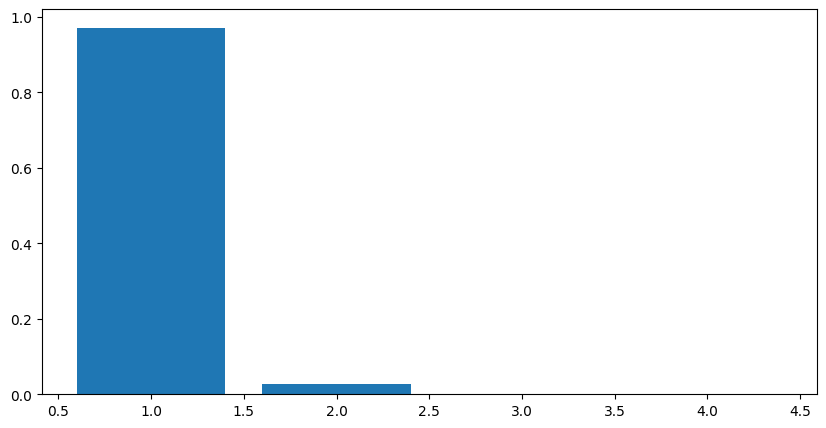

In [40]:
from sklearn.decomposition import PCA

#Reduce the number of features by half

pca = PCA(n_components=4)


x_pca = pca.fit_transform(X.drop("target", axis=1))


x_ax = []
y_ax = []
c=1
for i in (pca.explained_variance_ratio_):
    x_ax.append(c)
    y_ax.append(i)
    c = c+1
    
    
print(f"Total Variation Explained - {round(sum(y_ax)*100,1)}%")
plt.figure(figsize = (10,5))
plt.bar(x_ax,y_ax)
plt.show()

In [41]:
# Test Train Split for pca components
x_train_pca, x_test_pca, y_train, y_test = train_test_split(x_pca, X['target'], test_size=0.33, random_state=347)
print(colored(f"x_train_pca Shape = {x_train_pca.shape}, y_train Shape = {y_train.shape} \nx_test_pca Shape = {x_test_pca.shape}, y_test Shape = {y_test.shape}",'red',attrs = ['bold']))

x_train_pca Shape = (577, 4), y_train Shape = (577,) 
x_test_pca Shape = (285, 4), y_test Shape = (285,)


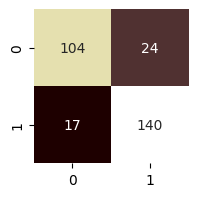


-------------------------------------------------------

              precision    recall  f1-score   support

           0       0.86      0.81      0.84       128
           1       0.85      0.89      0.87       157

    accuracy                           0.86       285
   macro avg       0.86      0.85      0.85       285
weighted avg       0.86      0.86      0.86       285



In [42]:
from sklearn.linear_model import LogisticRegression as LR

lr = LR(max_iter = 200, penalty = 'l2')

score = get_score(lr, x_train_pca, x_test_pca,y_train,y_test)

# A better 93% accuracy than previous Logistic Model and only with half the number of dimensions.


In [36]:
accuracy_score(y_val, lr.predict(x_test_pca))

ValueError: Found input variables with inconsistent numbers of samples: [426, 285]

In [6]:
from ydata_profiling import ProfileReport

In [9]:
profile = ProfileReport(train, title="YData Profiling Report", interactions = {"continuous": True, "targets": ["target", "area"]})

In [10]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 17/17 [00:00<00:00, 766.33it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [48]:
train.shape[0] + test.shape[0]

1718

In [45]:
all_data = pd.read_excel('data/Pistachio_16_Features_Dataset.xlsx', sheet_name='Pistachio_Dataset')
all_data

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,ROUNDNESS,COMPACTNESS,SHAPEFACTOR_1,SHAPEFACTOR_2,SHAPEFACTOR_3,SHAPEFACTOR_4,Class
0,63391,1568.4050,390.3396,236.7461,0.7951,284.0984,0.8665,73160,0.6394,1.6488,0.3238,0.7278,0.0062,0.0037,0.5297,0.8734,Kirmizi_Pistachio
1,68358,1942.1870,410.8594,234.7525,0.8207,295.0188,0.8765,77991,0.6772,1.7502,0.2277,0.7181,0.0060,0.0034,0.5156,0.9024,Kirmizi_Pistachio
2,73589,1246.5380,452.3630,220.5547,0.8731,306.0987,0.9172,80234,0.7127,2.0510,0.5951,0.6767,0.0061,0.0030,0.4579,0.9391,Kirmizi_Pistachio
3,71106,1445.2610,429.5291,216.0765,0.8643,300.8903,0.9589,74153,0.7028,1.9879,0.4278,0.7005,0.0060,0.0030,0.4907,0.9755,Kirmizi_Pistachio
4,80087,1251.5240,469.3783,220.9344,0.8823,319.3273,0.9657,82929,0.7459,2.1245,0.6425,0.6803,0.0059,0.0028,0.4628,0.9833,Kirmizi_Pistachio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2143,85983,1157.1160,444.3447,248.8627,0.8284,330.8730,0.9823,87536,0.6799,1.7855,0.8070,0.7446,0.0052,0.0029,0.5545,0.9900,Siit_Pistachio
2144,85691,2327.3459,439.8794,278.9297,0.7732,330.3107,0.8886,96439,0.6590,1.5770,0.1988,0.7509,0.0051,0.0033,0.5639,0.8892,Siit_Pistachio
2145,101136,1255.6190,475.2161,271.3299,0.8210,358.8459,0.9888,102286,0.7584,1.7514,0.8061,0.7551,0.0047,0.0027,0.5702,0.9987,Siit_Pistachio
2146,97409,1195.2150,452.1823,274.5764,0.7945,352.1718,0.9902,98376,0.7635,1.6468,0.8569,0.7788,0.0046,0.0028,0.6066,0.9989,Siit_Pistachio


In [56]:
all_data[all_data['AREA']==86261]

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,ROUNDNESS,COMPACTNESS,SHAPEFACTOR_1,SHAPEFACTOR_2,SHAPEFACTOR_3,SHAPEFACTOR_4,Class
1791,86261,1156.8521,456.5374,241.3351,0.8489,331.4075,0.9878,87326,0.6689,1.8917,0.81,0.7259,0.0053,0.0028,0.527,0.9968,Siit_Pistachio


In [54]:
test

,area,perimeter,major_axis,minor_axis,eccentricity,eqdiasq,solidity,convex_area,extent,aspect_ratio,roundness,compactness,shapefactor_1,shapefactor_2,shapefactor_3,shapefactor_4
0,93313,1862.7260,447.1666,278.4893,0.7824,344.6880,0.9361,99678,0.7607,1.6057,0.3380,0.7708,0.0048,0.0030,0.5942,0.9541
1,78778,2159.5969,439.1004,240.0113,0.8374,316.7069,0.9340,84345,0.7265,1.8295,0.2123,0.7213,0.0056,0.0030,0.5202,0.9517
2,74757,1661.6720,441.6910,225.3914,0.8600,308.5183,0.9359,79873,0.7255,1.9597,0.3402,0.6985,0.0059,0.0030,0.4879,0.9561
3,88074,2199.8889,460.8836,283.3717,0.7886,334.8721,0.8709,101133,0.6922,1.6264,0.2287,0.7266,0.0052,0.0032,0.5279,0.8586
4,79318,2589.4900,429.3032,279.5817,0.7589,317.7905,0.8666,91528,0.6634,1.5355,0.1486,0.7402,0.0054,0.0035,0.5480,0.8414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425,82531,1237.1060,493.5974,224.9682,0.8901,324.1631,0.9297,88769,0.7260,2.1941,0.6777,0.6567,0.0060,0.0027,0.4313,0.9463
426,67632,1172.7740,450.7991,199.7804,0.8964,293.4480,0.9534,70939,0.6800,2.2565,0.6179,0.6510,0.0067,0.0030,0.4237,0.9562
427,85519,1200.8210,480.6819,240.4698,0.8659,329.9790,0.9254,92409,0.7129,1.9989,0.7453,0.6865,0.0056,0.0028,0.4713,0.9420
428,86261,1156.8521,456.5374,241.3351,0.8489,331.4075,0.9878,87326,0.6689,1.8917,0.8100,0.7259,0.0053,0.0028,0.5270,0.9968


In [ ]:
test[test.area==86261]

,area,perimeter,major_axis,minor_axis,eccentricity,eqdiasq,solidity,convex_area,extent,aspect_ratio,roundness,compactness,shapefactor_1,shapefactor_2,shapefactor_3,shapefactor_4
428,86261,1156.8521,456.5374,241.3351,0.8489,331.4075,0.9878,87326,0.6689,1.8917,0.81,0.7259,0.0053,0.0028,0.527,0.9968
